In [1]:
import sys
print(sys.executable)

c:\Users\ASUS\OneDrive\Documents\CropDiseaseSeverity\.venv\Scripts\python.exe


In [2]:
import sys
import torch
import cv2
import numpy as np
import matplotlib
import ultralytics

print("Python:", sys.executable)
print("PyTorch:", torch.__version__)
print("Ultralytics:", ultralytics.__version__)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)

print("\nCUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("Running on CPU")

WARNING Ultralytics settings updated to the latest schema. Existing values were preserved where possible. 
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\ASUS\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Python: c:\Users\ASUS\OneDrive\Documents\CropDiseaseSeverity\.venv\Scripts\python.exe
PyTorch: 2.14.0+cpu
Ultralytics: 8.4.154
OpenCV: 5.0.0
NumPy: 2.5.3

CUDA available: False
Running on CPU


### IMPORTING MODEL

In [8]:
from ultralytics import YOLO

model = YOLO("models/best (1).pt")

print("YOLO model loaded successfully!")
print("Number of classes:", len(model.names))
print(model.names)

YOLO model loaded successfully!
Number of classes: 30
{0: 'Apple Scab Leaf', 1: 'Apple leaf', 2: 'Apple rust leaf', 3: 'Bell_pepper leaf', 4: 'Bell_pepper leaf spot', 5: 'Blueberry leaf', 6: 'Cherry leaf', 7: 'Corn Gray leaf spot', 8: 'Corn leaf blight', 9: 'Corn rust leaf', 10: 'Peach leaf', 11: 'Potato leaf', 12: 'Potato leaf early blight', 13: 'Potato leaf late blight', 14: 'Raspberry leaf', 15: 'Soyabean leaf', 16: 'Soybean leaf', 17: 'Squash Powdery mildew leaf', 18: 'Strawberry leaf', 19: 'Tomato Early blight leaf', 20: 'Tomato Septoria leaf spot', 21: 'Tomato leaf', 22: 'Tomato leaf bacterial spot', 23: 'Tomato leaf late blight', 24: 'Tomato leaf mosaic virus', 25: 'Tomato leaf yellow virus', 26: 'Tomato mold leaf', 27: 'Tomato two spotted spider mites leaf', 28: 'grape leaf', 29: 'grape leaf black rot'}


#### Importing the test image being used so far

In [11]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from ultralytics import YOLO, SAM

In [13]:
yolo_model = YOLO("models/best (1).pt")

print("YOLO loaded!")
print("Classes:", len(yolo_model.names))

YOLO loaded!
Classes: 30


In [14]:
sam_model = SAM("models/sam2_b.pt")

print("SAM2 loaded!")

SAM2 loaded!


- Defining image paths

In [15]:
test_images = [
    r"test_images/286_1600.jpg",
    r"test_images/220px-Sporulation_on_leaf_JPG.jpg",
    r"test_images/IMG_1982.jpg"
]

for path in test_images:
    print(os.path.basename(path))

286_1600.jpg
220px-Sporulation_on_leaf_JPG.jpg
IMG_1982.jpg


- Verifying the extracted images


File: 286_1600.jpg
Shape: (416, 416, 3)


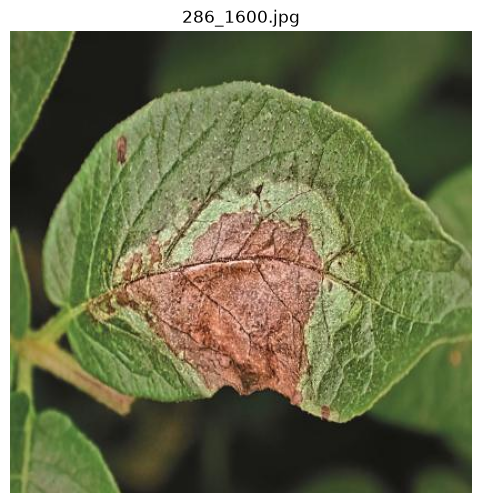


File: 220px-Sporulation_on_leaf_JPG.jpg
Shape: (416, 416, 3)


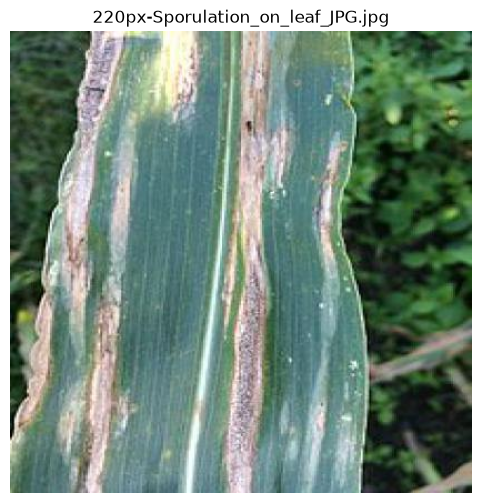


File: IMG_1982.jpg
Shape: (416, 416, 3)


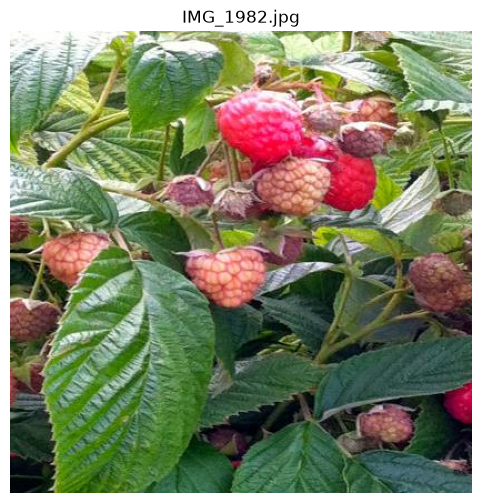

In [16]:
for path in test_images:

    img = cv2.imread(path)

    print("\nFile:", os.path.basename(path))
    print("Shape:", img.shape)

    plt.figure(figsize=(6, 6))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(os.path.basename(path))
    plt.axis("off")
    plt.show()

- Running YOLO on all 3 of the images

In [17]:
yolo_results = []

for path in test_images:

    results = yolo_model(path)

    result = results[0]

    print("\n" + "=" * 50)
    print("IMAGE:", os.path.basename(path))
    print("DETECTIONS:", len(result.boxes))

    for i, box_data in enumerate(result.boxes):

        cls = int(box_data.cls[0].item())
        conf = float(box_data.conf[0].item())

        bbox = box_data.xyxy[0].cpu().numpy().astype(int)

        print(
            f"Detection {i}:",
            yolo_model.names[cls],
            "| Confidence:", round(conf, 3),
            "| Box:", bbox
        )

    yolo_results.append(result)


image 1/1 c:\Users\ASUS\OneDrive\Documents\CropDiseaseSeverity\test_images\286_1600.jpg: 640x640 1 Potato leaf late blight, 376.0ms
Speed: 31.0ms preprocess, 376.0ms inference, 30.9ms postprocess per image at shape (1, 3, 640, 640)

IMAGE: 286_1600.jpg
DETECTIONS: 1
Detection 0: Potato leaf late blight | Confidence: 0.302 | Box: [ 23  33 416 357]

image 1/1 c:\Users\ASUS\OneDrive\Documents\CropDiseaseSeverity\test_images\220px-Sporulation_on_leaf_JPG.jpg: 640x640 1 Corn leaf blight, 254.3ms
Speed: 131.1ms preprocess, 254.3ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 640)

IMAGE: 220px-Sporulation_on_leaf_JPG.jpg
DETECTIONS: 1
Detection 0: Corn leaf blight | Confidence: 0.76 | Box: [ 13   0 324 416]

image 1/1 c:\Users\ASUS\OneDrive\Documents\CropDiseaseSeverity\test_images\IMG_1982.jpg: 640x640 1 Apple leaf, 1 Cherry leaf, 259.4ms
Speed: 11.4ms preprocess, 259.4ms inference, 3.2ms postprocess per image at shape (1, 3, 640, 640)

IMAGE: IMG_1982.jpg
DETECTIONS: 2
Dete

- selecting the highest confidence YOLO detection

In [18]:
selected_boxes = []

for result in yolo_results:

    if len(result.boxes) == 0:
        selected_boxes.append(None)
        continue

    best_idx = result.boxes.conf.argmax()

    best_box = (
        result.boxes[best_idx]
        .xyxy[0]
        .cpu()
        .numpy()
        .astype(int)
    )

    selected_boxes.append(best_box)

    cls = int(result.boxes[best_idx].cls[0].item())
    conf = float(result.boxes[best_idx].conf[0].item())

    print(
        "\nSelected:",
        yolo_model.names[cls],
        "| Confidence:", round(conf, 3),
        "| Box:", best_box
    )


Selected: Potato leaf late blight | Confidence: 0.302 | Box: [ 23  33 416 357]

Selected: Corn leaf blight | Confidence: 0.76 | Box: [ 13   0 324 416]

Selected: Cherry leaf | Confidence: 0.704 | Box: [ 22 192 187 416]


- visualization

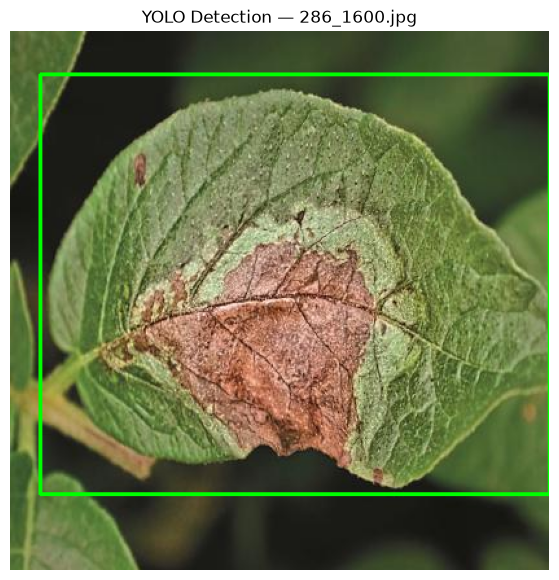

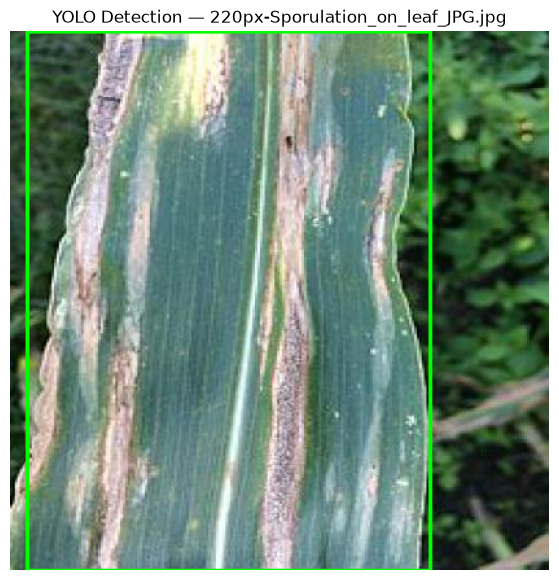

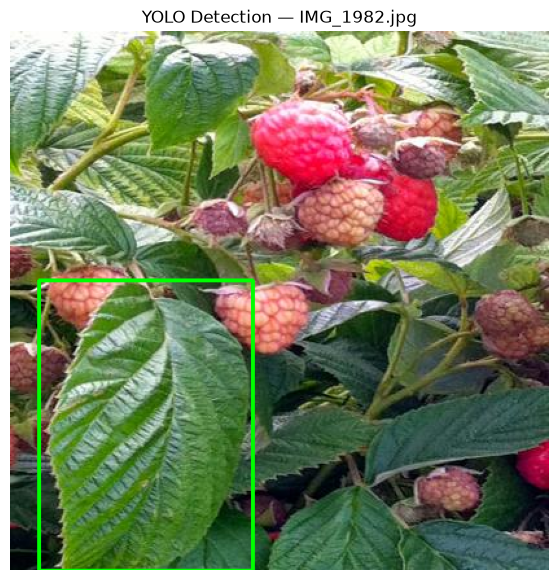

In [19]:
for path, box in zip(test_images, selected_boxes):

    if box is None:
        print("No detection:", os.path.basename(path))
        continue

    img = cv2.imread(path)

    x1, y1, x2, y2 = box

    display_img = img.copy()

    cv2.rectangle(
        display_img,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),
        2
    )

    plt.figure(figsize=(7, 7))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.title(f"YOLO Detection — {os.path.basename(path)}")
    plt.axis("off")
    plt.show()

#### Using YOLO Annotation Boxes as SAM's anchor

In [20]:
sam_results = []

for path, box in zip(test_images, selected_boxes):

    if box is None:
        sam_results.append(None)
        continue

    print("\nRunning SAM on:", os.path.basename(path))

    result = sam_model(
        path,
        bboxes=[box]
    )

    sam_results.append(result)

    print("SAM completed.")


Running SAM on: 286_1600.jpg



c:\Users\ASUS\OneDrive\Documents\CropDiseaseSeverity\.venv\Lib\site-packages\ultralytics\models\sam\predict.py:326: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_new.cpp:255.)
  bboxes = torch.as_tensor(bboxes, dtype=self.torch_dtype, device=self.device)


image 1/1 c:\Users\ASUS\OneDrive\Documents\CropDiseaseSeverity\test_images\286_1600.jpg: 1024x1024 1 0, 21786.9ms
Speed: 29.9ms preprocess, 21786.9ms inference, 23.0ms postprocess per image at shape (1, 3, 1024, 1024)
SAM completed.

Running SAM on: 220px-Sporulation_on_leaf_JPG.jpg

image 1/1 c:\Users\ASUS\OneDrive\Documents\CropDiseaseSeverity\test_images\220px-Sporulation_on_leaf_JPG.jpg: 1024x1024 1 0, 20463.5ms
Speed: 45.6ms preprocess, 20463.5ms inference, 12.7ms postprocess per image at shape (1, 3, 1024, 1024)
SAM completed.

Running SAM on: IMG_1982.jpg

image 1/1 c:\Users\ASUS\OneDrive\Documents\CropDiseaseSeverity\test_images\IMG_1982.jpg: 1024x1024 1 0, 19266.8ms
Speed: 47.8ms preprocess, 19266.8ms inference, 5.8ms postprocess per image at shape (1, 3, 1024, 1024)
SAM completed.


- extracting SAM Masks

In [21]:
sam_masks = []

for path, results in zip(test_images, sam_results):

    if results is None:
        sam_masks.append(None)
        continue

    masks = results[0].masks

    print("\n" + "=" * 50)
    print("IMAGE:", os.path.basename(path))

    if masks is None:
        print("No SAM mask produced.")
        sam_masks.append(None)
        continue

    print("Number of SAM masks:", len(masks.data))
    print("Raw mask shape:", masks.data.shape)

    mask = masks.data[0].cpu().numpy()

    print("Mask min:", mask.min())
    print("Mask max:", mask.max())
    print("Mask pixels:", np.sum(mask > 0))

    sam_masks.append(mask)


IMAGE: 286_1600.jpg
Number of SAM masks: 1
Raw mask shape: torch.Size([1, 416, 416])
Mask min: False
Mask max: True
Mask pixels: 85821

IMAGE: 220px-Sporulation_on_leaf_JPG.jpg
Number of SAM masks: 1
Raw mask shape: torch.Size([1, 416, 416])
Mask min: False
Mask max: True
Mask pixels: 115553

IMAGE: IMG_1982.jpg
Number of SAM masks: 1
Raw mask shape: torch.Size([1, 416, 416])
Mask min: False
Mask max: True
Mask pixels: 26447


- Visualizing SAM Masks

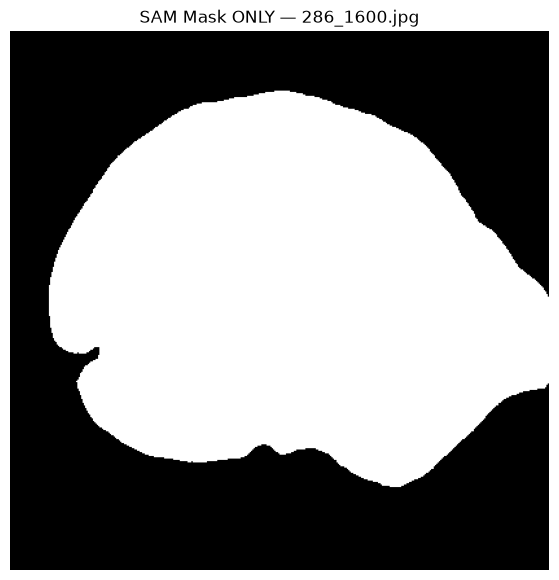

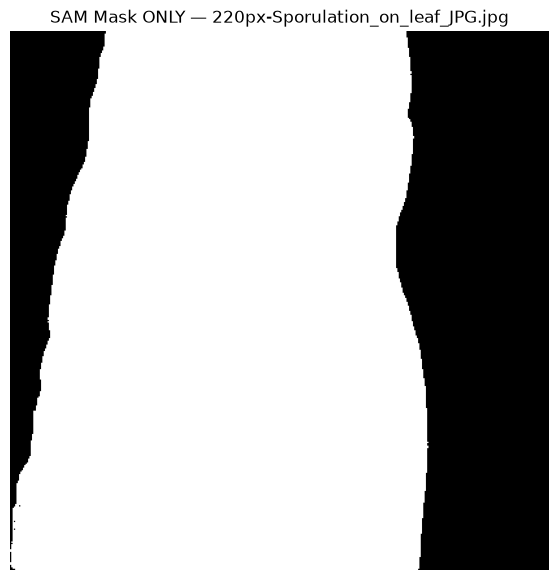

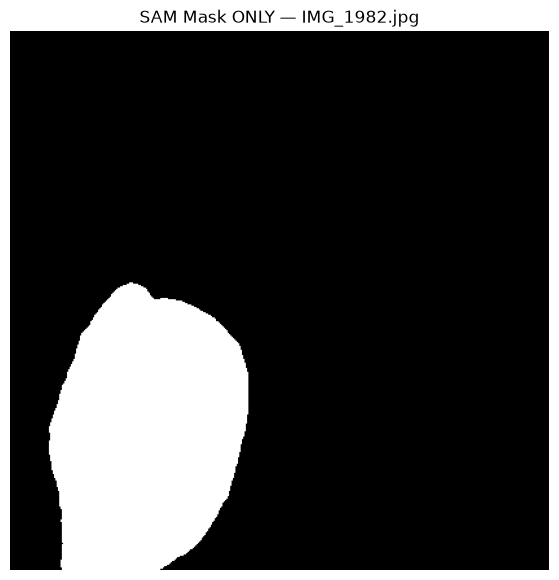

In [22]:
for path, mask in zip(test_images, sam_masks):

    if mask is None:
        continue

    plt.figure(figsize=(7, 7))

    plt.imshow(mask, cmap="gray")

    plt.title(
        f"SAM Mask ONLY — {os.path.basename(path)}"
    )

    plt.axis("off")
    plt.show()

- resizing SAM Mask to original image

In [23]:
resized_masks = []

for path, mask in zip(test_images, sam_masks):

    if mask is None:
        resized_masks.append(None)
        continue

    img = cv2.imread(path)

    h, w = img.shape[:2]

    resized_mask = cv2.resize(
        mask.astype(np.uint8),
        (w, h),
        interpolation=cv2.INTER_NEAREST
    )

    resized_masks.append(resized_mask)

- SAM Overlay

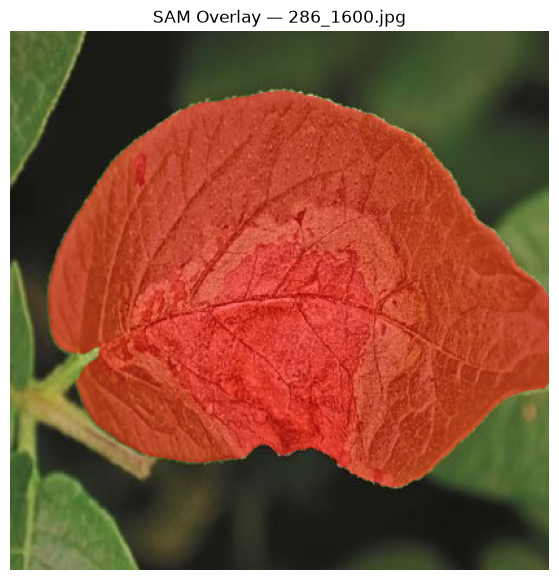

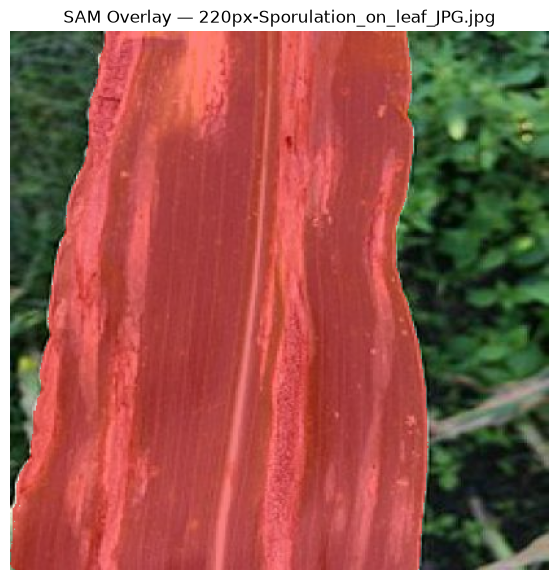

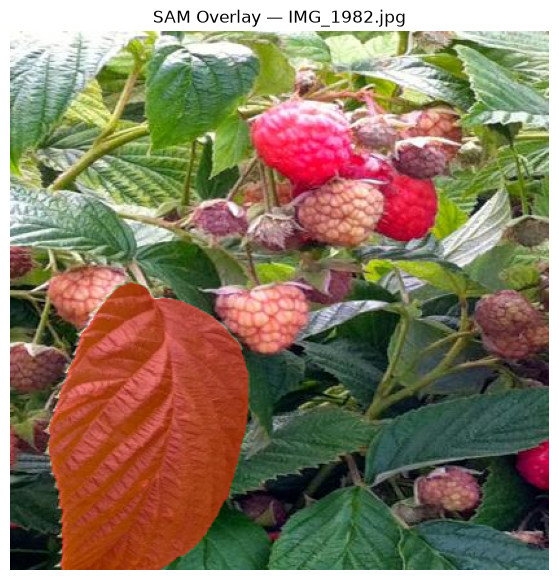

In [24]:
for path, mask in zip(test_images, resized_masks):

    if mask is None:
        continue

    img = cv2.imread(path)

    overlay = img.copy()

    mask_bool = mask > 0

    overlay[mask_bool] = (
        0.5 * overlay[mask_bool] +
        0.5 * np.array([0, 0, 255])
    ).astype(np.uint8)

    plt.figure(figsize=(7, 7))

    plt.imshow(
        cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
    )

    plt.title(
        f"SAM Overlay — {os.path.basename(path)}"
    )

    plt.axis("off")
    plt.show()

- basic SAM statistics

In [25]:
for path, box, mask in zip(
    test_images,
    selected_boxes,
    resized_masks
):

    if mask is None or box is None:
        continue

    x1, y1, x2, y2 = box

    box_width = x2 - x1
    box_height = y2 - y1

    box_area = box_width * box_height

    sam_pixels = np.sum(mask > 0)

    print("\n" + "=" * 50)
    print("Image:", os.path.basename(path))
    print("YOLO box:", box)
    print("YOLO box area:", box_area)
    print("SAM pixels:", sam_pixels)

    if box_area > 0:
        print(
            "SAM / YOLO box:",
            round(100 * sam_pixels / box_area, 2),
            "%"
        )


Image: 286_1600.jpg
YOLO box: [ 23  33 416 357]
YOLO box area: 127332
SAM pixels: 85821
SAM / YOLO box: 67.4 %

Image: 220px-Sporulation_on_leaf_JPG.jpg
YOLO box: [ 13   0 324 416]
YOLO box area: 129376
SAM pixels: 115553
SAM / YOLO box: 89.32 %

Image: IMG_1982.jpg
YOLO box: [ 22 192 187 416]
YOLO box area: 36960
SAM pixels: 26447
SAM / YOLO box: 71.56 %


- Saving the results

In [26]:
os.makedirs("outputs/sam_test", exist_ok=True)

In [27]:
for path, mask in zip(test_images, resized_masks):

    if mask is None:
        continue

    filename = os.path.splitext(
        os.path.basename(path)
    )[0]

    mask_path = f"outputs/sam_test/{filename}_sam_mask.png"

    cv2.imwrite(
        mask_path,
        (mask * 255).astype(np.uint8)
    )

    print("Saved:", mask_path)

Saved: outputs/sam_test/286_1600_sam_mask.png
Saved: outputs/sam_test/220px-Sporulation_on_leaf_JPG_sam_mask.png
Saved: outputs/sam_test/IMG_1982_sam_mask.png


In [28]:
for path, mask in zip(test_images, resized_masks):

    if mask is None:
        continue

    img = cv2.imread(path)

    overlay = img.copy()

    mask_bool = mask > 0

    overlay[mask_bool] = (
        0.5 * overlay[mask_bool] +
        0.5 * np.array([0, 0, 255])
    ).astype(np.uint8)

    filename = os.path.splitext(
        os.path.basename(path)
    )[0]

    overlay_path = (
        f"outputs/sam_test/{filename}_sam_overlay.jpg"
    )

    cv2.imwrite(overlay_path, overlay)

    print("Saved:", overlay_path)

Saved: outputs/sam_test/286_1600_sam_overlay.jpg
Saved: outputs/sam_test/220px-Sporulation_on_leaf_JPG_sam_overlay.jpg
Saved: outputs/sam_test/IMG_1982_sam_overlay.jpg


In [ ]:
img = cv2.imread(test_images[0])
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img_rgb)
plt.title("Click INSIDE an obvious diseased/brown region")
plt.axis("on")

point = plt.ginput(1)

plt.close()

print("Clicked point:", point)